# Evaluation of the new framework

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import MultiModalEncoder, ClinicalLinkageModule, concat_modality_embeddings
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map, RegularizationModule
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.training.loops import modality_wise_contrastive_learning, new_predictive_learning, build_run_name
from gbmhackathon.training.cv import get_mccv_loaders
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(16)
torch.get_num_threads()

16

In [4]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [5]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
# "spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [6]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=1.0)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cpu 
Using device: cpu
By keeping 100.00% of dropout augmented samples we went from:
468 dropout samples (80.41% dropout in dataset) -- to --> 468 dropout samples (80.41% dropout in dataset)
Dataset size: 582


In [7]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

In [8]:
raw_emb = next(iter(dataloader))[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([582, 1536])
clinical torch.Size([582, 20])
wes torch.Size([582, 1790])
bulk torch.Size([582, 3072])
scRNA torch.Size([582, 3072])


In [9]:
patient_map = make_patient_map(dataset)

In [10]:
def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

In [89]:
out = 32
norm_fn = nn.BatchNorm1d
smoothing_fn = SmoothingFunction(bound=-50, slope=0.1, rate=-5)
act_fn = [nn.GELU, nn.GELU, smoothing_fn]
base_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

hne_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

clinical_cfg = {"layers": [256,128,out],
        "dropout": 0.3,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

wes_cfg = {"layers": [512,128,out],
        "dropout": 0.3,
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

rna_cfg = {"layers": [1024,256,out], #[1024,128,512,128,out],
        "dropout": 0.3,
        "act_fn":act_fn, #[nn.GELU, nn.GELU, nn.GELU, nn.GELU, smoothing_fn],
        "norm_layer":None,
        "device":device}


hne_cfg = adapt_base_config(hne_cfg, inpute_size_dict["hne"])
#spatial_cfg = adapt_base_config(small_capacity_cfg, inpute_size_dict["spatial"])
clinical_cfg = adapt_base_config(clinical_cfg, inpute_size_dict["clinical"])
wes_cfg = adapt_base_config(wes_cfg, inpute_size_dict["wes"])
bulk_cfg = adapt_base_config(rna_cfg, inpute_size_dict["bulk"])
sc_cfg = adapt_base_config(rna_cfg, inpute_size_dict["scRNA"])

In [90]:
mme_bulk_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": bulk_cfg}

mme_hne_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": hne_cfg}

mme_sc_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": sc_cfg}

mme_wes_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": wes_cfg}

mme_clinical_cfg = {"net_type": "mlp",
                "device": device,
                "net_config": clinical_cfg}

In [91]:
mme_cfg = {"hne_cfg":mme_hne_cfg, 
           "clinical_cfg":mme_clinical_cfg, 
           "wes_cfg":mme_wes_cfg, 
           #"spatial_cfg":mme_spatial_cfg,
           "bulk_cfg":mme_bulk_cfg,
          "sc_cfg":mme_sc_cfg}

In [92]:
base_head_cfg = {"layers": [out*len(mme_cfg),1024,512,5],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.ReLU, nn.ReLU, None],
        "norm_layer":norm_fn,
        "device":device}
head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": base_head_cfg}

In [93]:
regularizer_cfg = {"reg_coeff":0.1,
        # "use_invariance":False,
        # "inv_coeff":25.0,
        "use_variance":True,
        "var_coeff":1.0,
        "use_covariance":True,
        "cov_coeff":1.0,
        "var_gamma":1.0,
        "var_eps":1e-4,
        # "use_soft_orth":False,
        # "so_coeff":1.0,
        # "use_srip":False,
        # "srip_coeff":1.0,
        # "srip_iters":1,
}

In [94]:
mme = instantiate(mme_cfg,MultiModalEncoder)

EPOCHS_I = 100
base_lr_I = 1e-3
eta_min_coef = 0.05
scheduler_I_class = torch.optim.lr_scheduler.CosineAnnealingLR
scheduler_I_cfg = {"T_max":EPOCHS_I,
                  "eta_min":"dynamic"}

contrastive_loss_cfg = {"modalities":list(name_emb_dict.keys()),
                        "patient_map":patient_map,
                        "temperature":0.05,
                        "similarity":'nt-xent',
                        "use_all_positives":False,
                        "alpha":0,
                        "bound":-50,
                        "slope":0.1,
                        "rate":-5,
                        "warn":False,
                       "smoothing_func":False}

# Optimization for Phase I
optimizer_I = Adam(mme.parameters(), lr=base_lr_I)
scheduler_I_cfg["optimizer"] = optimizer_I
if "eta_min" in scheduler_I_cfg.keys():
    if scheduler_I_cfg["eta_min"] == "dynamic":
        scheduler_I_cfg["eta_min"] = eta_min_coef * base_lr_I
scheduler_I = instantiate(scheduler_I_cfg, scheduler_I_class)

contrastive_loss_fn = instantiate(contrastive_loss_cfg, RegularizedInfoNCELoss)

modalities = next(iter(dataloader))[2].keys()
    
# A contrastive loss module per modality
modality_contrastive_loss_fn = {}
for modality in modalities:
    contrastive_loss_cfg_mod = contrastive_loss_cfg.copy()
    contrastive_loss_cfg_mod['modalities'] = [modality]
    modality_contrastive_loss_fn[modality] = instantiate(contrastive_loss_cfg_mod, RegularizedInfoNCELoss)

# An optimizer per modality
modality_optimizers = {modality:Adam(mme.modality_net_map[modality].parameters(), lr=base_lr_I) for modality in modalities}

# A scheduler per modality
modality_schedulers = {}
for modality in modalities:
    # Same schedule for all modalities for now, but it can be configurable
    scheduler_cfg = scheduler_I_cfg.copy()
    scheduler_cfg["optimizer"] = modality_optimizers[modality]
    if "eta_min" in scheduler_I_cfg.keys():
        if scheduler_cfg["eta_min"] == "dynamic":
            scheduler_cfg["eta_min"] = eta_min_coef * base_lr_I
    modality_schedulers[modality] = instantiate(scheduler_cfg, scheduler_I_class)

# A regularization method per modality
regularizer_dict = {}
for modality in modalities:
    regularizer_dict[modality] = instantiate(regularizer_cfg, RegularizationModule)

{'net_type': 'mlp', 'device': 'cpu', 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, SmoothingFunction()], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cpu'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found


EPOCH 1 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.4104
EPOCH 2 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.4532
EPOCH 3 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.0755
EPOCH 4 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.2663
EPOCH 5 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.0755
EPOCH 6 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.4292
EPOCH 7 AVERAGE TOTAL LOSS ACROSS MODALITIES: 7.7615
EPOCH 8 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.2314
EPOCH 9 AVERAGE TOTAL LOSS ACROSS MODALITIES: 8.8502
EPOCH 10 AVERAGE TOTAL LOSS ACROSS MODALITIES: 9.6572
EPOCH 11 AVERAGE TOTAL LOSS ACROSS MODALITIES: 10.6153
EPOCH 12 AVERAGE TOTAL LOSS ACROSS MODALITIES: 11.5855
EPOCH 13 AVERAGE TOTAL LOSS ACROSS MODALITIES: 12.6523
EPOCH 14 AVERAGE TOTAL LOSS ACROSS MODALITIES: 13.5012
EPOCH 15 AVERAGE TOTAL LOSS ACROSS MODALITIES: 13.9608
EPOCH 16 AVERAGE TOTAL LOSS ACROSS MODALITIES: 14.0387
EPOCH 17 AVERAGE TOTAL LOSS ACROSS MODALITIES: 13.9552
EPOCH 18 AVERAGE TOTAL LOSS ACROSS MODALITIES: 13.7854
EPOCH 19 AVERAGE TOTAL LOSS A

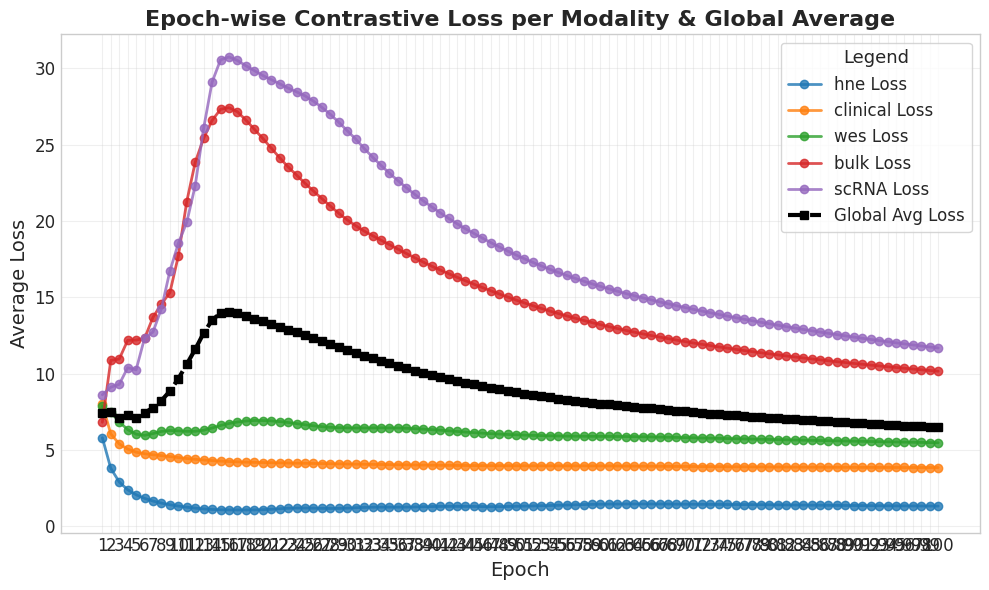

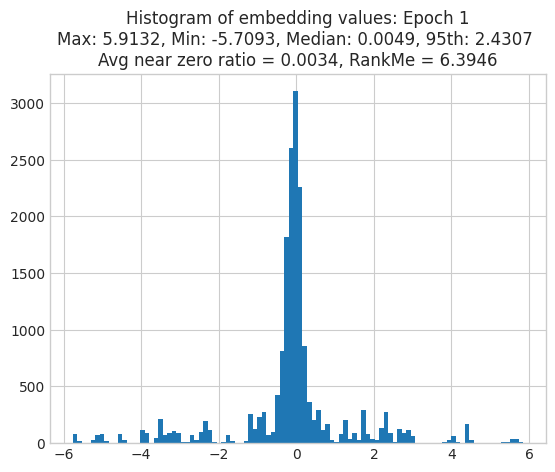

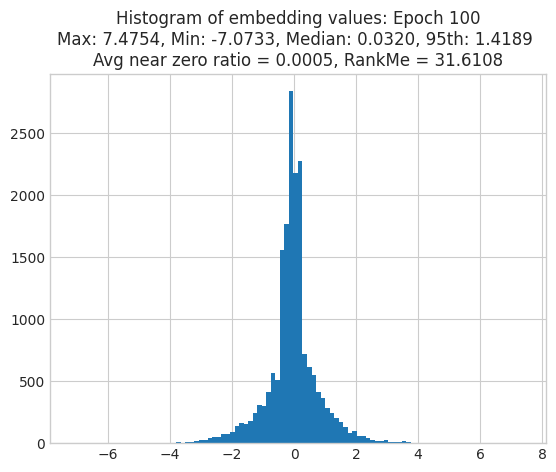

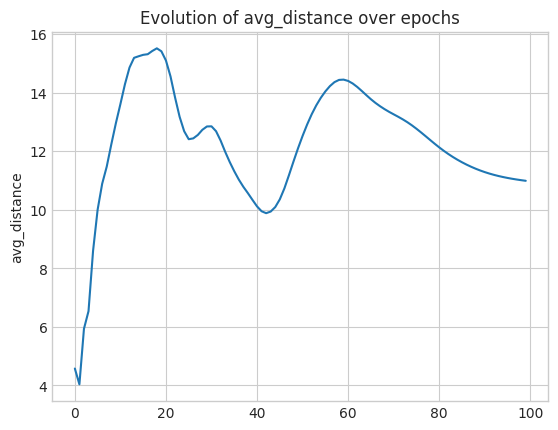

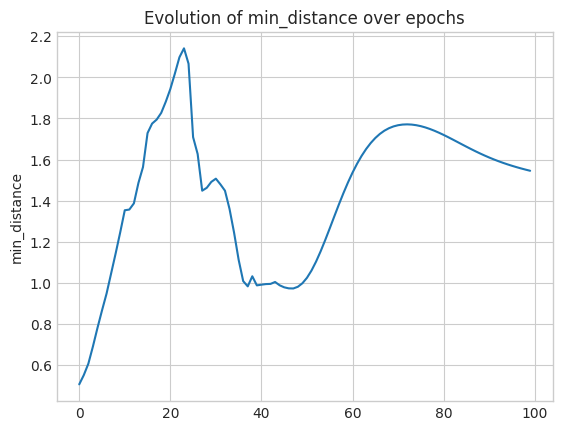

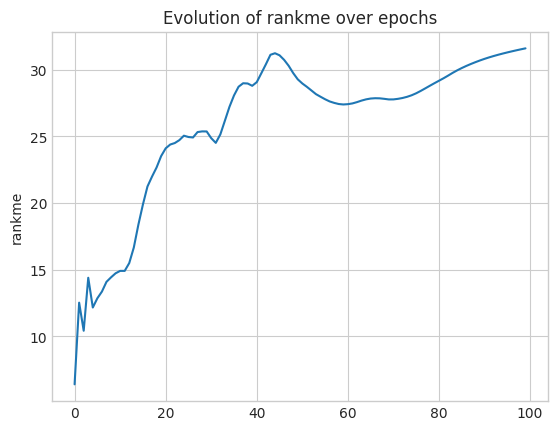

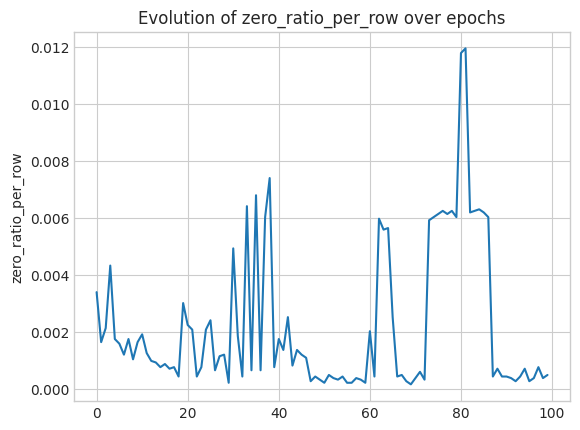

In [95]:
modality_wise_contrastive_learning(mme, 
                                   dataloader, 
                                   EPOCHS_I, 
                                   base_lr_I,
                                   modality_optimizers, 
                                   modality_contrastive_loss_fn, 
                                   modality_schedulers,
                                   regularizer_dict,
                                   batch_all=batch_all,
                                   make_gifs=False,
                                   analyze_emb=True)

## Use the trained MME to compute and save representations of true patient samples to use for the clinical linkage phase

In [18]:
run_name = build_run_name(
    model=mme,
    epochs=EPOCHS_I,
    base_lr=base_lr_I,
    eta_min_coef=eta_min_coef,
    scheduler_class=scheduler_I_class,
    scheduler_cfg=scheduler_I_cfg,
    contrastive_loss_cfg=contrastive_loss_cfg,
    modality_list=list(name_emb_dict.keys())
)

In [19]:
mme_emb_dict = mme(batch_all[2]) # Retrieves X_dict
folder = "mme_embeddings"
save_path = f"{folder}/{run_name}.pkl"
os.makedirs(folder, exist_ok=True)

with open(save_path, "wb") as f:
    pkl.dump(mme_emb_dict, f)

# Set everything up for clinical linkage phase

In [20]:
reg_head_cfg = {"layers": [out*len(mme_cfg),512,256,1],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}
binary_clf_head_cfg = {"layers": [out*len(mme_cfg),512,256,2],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}
multi_clf_head_cfg = {"layers": [out*len(mme_cfg),512,256,3],
        "dropout": 0.3,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":[nn.GELU, nn.GELU, None],
        "norm_layer":norm_fn,
        "device":device}

In [21]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": binary_clf_head_cfg}
mgmt_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": multi_clf_head_cfg}

In [22]:
# ATTENTION !!!! MUST BE THIS EXACT ORDER FOR PREDICTIVE TASKS: 
# ['os_years', 'pfs_years', 'largest_diameter_of_the_primary_tumour_mm_duplicated_0', 'recurrent_sample']
# OR ['os_years', 'pfs_years', 'recurrent_sample', 'mgmt_promoter_methylation'] if using latest targets
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "recurrency":recurrency_head_cfg,
                  "mgmt":mgmt_head_cfg}}
refinement_cfg = {"emb_size": out*len(mme_cfg),
                "cross_modality_heads": 4,
                "avail_mods_len":5,
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": 0.3,
                "device": device}
clf_targets = ['recurrency', 'mgmt']
clf_targets_dict = {'recurrency':2, 'mgmt':3}

# Monte Carlo Cross Validation
Instantiation must be done for each fold

In [23]:
n_splits = 30
test_size = 0.8
t_batch = 64 # training batch size
v_batch = 256 # evaluation batch size
random_state = 6262

In [24]:
cv_scores = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    
for train_loader, val_loader in get_mccv_loaders(dataset, 
                                                 collate_predictive,
                                                 n_splits=n_splits, 
                                                 test_size=test_size, 
                                                 train_batch_size=t_batch, 
                                                 val_batch_size=v_batch, 
                                                 device=device, 
                                                 random_state=random_state):
    EPOCHS_II = 100
    base_lr_II = 1e-3
    scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
    scheduler_II_cfg = {"T_max":EPOCHS_II,
                        "eta_min":"dynamic"}
    clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)
    # Optimization for Phase II
    optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
    scheduler_II_cfg["optimizer"] = optimizer_II
    if "eta_min" in scheduler_II_cfg.keys():
        if scheduler_II_cfg["eta_min"] == "dynamic":
            scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
    scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

    # Training loop with validation at the end of each epoch on the validation set
    new_predictive_learning(mme, clm, 
                          train_loader,
                          EPOCHS_II, 
                          base_lr_II, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          v_dataloader=val_loader,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all, # No worries, it is used in eval mode under the hood so not seen by model
                          make_gifs=False,
                          )
    # Evaluation metrics are computed on the validation set after training.
    clm.eval()
    all_val_predictions = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    all_val_targets = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    for batch in val_loader:
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        
        contrastive_outputs = mme(X_dict)
        task_outputs, patient_embeddings = clm(contrastive_outputs, avail_mods)
        
        overall_loss = torch.tensor(0, device=device)
        # Regression losses
        for i, key in enumerate(task_outputs.keys()):
            if key not in clf_targets:
                all_val_predictions[key].append(task_outputs[key].squeeze())
                all_val_targets[key].append(batch_targets[:,i])
            
        # Classification losses
        for i, key in enumerate(clf_targets):
            if i == 0:
                start_idx = len(task_outputs.keys()) - len(clf_targets)
            else:
                start_idx = end_idx - 1 # last end_idx
            # clf_targets_dict is a dict that maps each clf target to the number of classes it holds
            end_idx = start_idx + clf_targets_dict[key]
            all_val_predictions[key].append(task_outputs[key])
            all_val_targets[key].append(batch_targets[:,start_idx:end_idx])
            
    for task in all_val_predictions.keys():
        all_task_pred = torch.cat(all_val_predictions[task], dim=0)
        all_task_true = torch.cat(all_val_targets[task], dim=0)
        if task not in clf_targets:
            score = torch.sqrt(nn.MSELoss()(all_task_pred, all_task_true)).item()
        else:
            score = f1_score(torch.argmax(all_task_true, dim=1).detach().numpy(), 
                             torch.argmax(all_task_pred, dim=1).detach().numpy(), 
                             average='macro', zero_division=0)
        cv_scores[task].append(score)

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
torch.Size([466]) torch.Size([466])004718060
torch.Size([466]) torch.Size([466])
torch.Size([466]) torch.Size([466])
torch.Size([466, 2]) torch.Size([466, 2])
torch.Size([466, 3]) torch.Size([466, 3])
Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
tor

In [25]:
evaluations = {}
for task in cv_scores.keys():
    evaluations[task] = np.mean(cv_scores[task])
    print(f"MCCV score on task {task}: {evaluations[task]}")

MCCV score on task os: 197.98252019484838
MCCV score on task pfs: 204.98910132249196
MCCV score on task diameter: 45.893680067857105
MCCV score on task recurrency: 0.4786594683210945
MCCV score on task mgmt: 0.3231361526522194
